# Phase 4: Non-symbolic Models — EPC Energy Score Prediction

This notebook implements the **non-symbolic model** component of our modeling pipeline, mirroring the setup of the Decision Tree notebook (`03_decision_tree.ipynb`) so results are directly comparable.

**Task:** Regression — predict `CURRENT_ENERGY_EFFICIENCY` (1–147 scale) from physical building characteristics only.

**Post-prediction binning:** Predicted score ≥ 69 → Efficient (A–C), < 69 → Inefficient (D–G)

**Models trained:**
1. Random Forest — bagging ensemble of decision trees
2. XGBoost — gradient boosting (sequential error correction)
3. LightGBM — gradient boosting (faster, leaf-wise growth)

### Notebook structure
1. Setup & Data Load
2. Define Features & Target
3. Train / Test Split (same `random_state=42` as Decision Tree notebook)
4. Preprocessing Pipeline
5. Random Forest — default + tuned
6. XGBoost — default + tuned
7. LightGBM — default + tuned
8. Feature Importance Comparison
9. Summary Table (compared against Decision Tree baseline)

## 1. Setup & Data Load

In [3]:
!pip install xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 2.9 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.2 MB/s eta 0:00:000:00:010:00:01:01


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Load Phase 3 output — same file as Decision Tree notebook
df = pd.read_parquet('manchester_epc_phase3_final.parquet')

print(f"Dataset shape: {df.shape}")
print(f"\nTarget — CURRENT_ENERGY_EFFICIENCY:")
print(df['CURRENT_ENERGY_EFFICIENCY'].describe())

Dataset shape: (266470, 69)

Target — CURRENT_ENERGY_EFFICIENCY:
count    266470.000000
mean         68.935618
std          11.645365
min           1.000000
25%          63.000000
50%          70.000000
75%          77.000000
max         147.000000
Name: CURRENT_ENERGY_EFFICIENCY, dtype: float64


## 2. Define Features & Target

Identical setup to the Decision Tree notebook — same target, same excluded columns, same feature set. This guarantees direct comparability.

In [7]:
TARGET = 'CURRENT_ENERGY_EFFICIENCY'
BINNING_LABEL = 'target_is_efficient'
THRESHOLD = 69

EXCLUDE = [TARGET, BINNING_LABEL]
feature_cols = [c for c in df.columns if c not in EXCLUDE]

X = df[feature_cols]
y = df[TARGET]

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Total features  : {X.shape[1]}")
print(f"  Numeric       : {len(numeric_cols)}")
print(f"  Categorical   : {len(categorical_cols)}")
print(f"\nTarget range    : {y.min()} - {y.max()}  |  mean: {y.mean():.1f}  |  std: {y.std():.1f}")

Total features  : 67
  Numeric       : 67
  Categorical   : 0

Target range    : 1 - 147  |  mean: 68.9  |  std: 11.6


## 3. Train / Test Split

`random_state=42` is identical to the Decision Tree notebook, producing the same train/test rows. The test set is held out for final evaluation only.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set : {X_train.shape[0]:,} rows")
print(f"Test set  : {X_test.shape[0]:,} rows")

Train set : 213,176 rows
Test set  : 53,294 rows


## 4. Preprocessing Pipeline

Same preprocessing pipeline as the Decision Tree notebook. Median imputation for numeric features, OHE for categorical features (no categorical columns remain after Phase 3, but the branch is defined for robustness). All transformations are inside a `Pipeline` so they are fitted only on training folds during cross-validation — no data leakage.

In [11]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
], remainder='drop')

print("Preprocessor defined — numeric: median imputation | categorical: 'Unknown' fill + OHE")

Preprocessor defined — numeric: median imputation | categorical: 'Unknown' fill + OHE


## 5. Random Forest

**How it works:** A Random Forest trains many decision trees in parallel, each on a random subset of the data and a random subset of features (bagging + feature randomness). The final prediction is the average of all tree predictions. This averaging reduces variance dramatically compared to a single tree.

**Why non-symbolic:** A single tree gives human-readable rules. 100+ trees averaged together do not — the ensemble is a black box.

In [13]:
# --- 5.1 Default Random Forest ---
rf_default_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_default_rmse = cross_val_score(
    rf_default_pipeline, X_train, y_train,
    cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1
)
rf_default_mae = cross_val_score(
    rf_default_pipeline, X_train, y_train,
    cv=10, scoring='neg_mean_absolute_error', n_jobs=-1
)

print("=== DEFAULT RANDOM FOREST ===")
print(f"CV RMSE : {-rf_default_rmse.mean():.3f} ± {rf_default_rmse.std():.3f}")
print(f"CV MAE  : {-rf_default_mae.mean():.3f} ± {rf_default_mae.std():.3f}")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i

=== DEFAULT RANDOM FOREST ===
CV RMSE : 5.803 ± 0.043
CV MAE  : 3.862 ± 0.024


In [ ]:
# --- 5.2 Tuned Random Forest (RandomizedSearchCV) ---
# RandomizedSearchCV is used instead of GridSearchCV because RF is slow — 40 random combos
# covers the space far more efficiently than an exhaustive grid.
rf_tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    'model__n_estimators'     : [100, 200, 300],
    'model__max_depth'        : [10, 20, 30, None],
    'model__min_samples_split': [2, 10, 50],
    'model__min_samples_leaf' : [1, 5, 20],
    'model__max_features'     : ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    rf_tuning_pipeline,
    rf_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

rf_search.fit(X_train, y_train)

print("\n=== TUNED RANDOM FOREST ===")
print(f"Best CV RMSE : {-rf_search.best_score_:.3f}")
print(f"Best params  : {rf_search.best_params_}")

rf_tuned_mae = cross_val_score(
    rf_search.best_estimator_, X_train, y_train,
    cv=10, scoring='neg_mean_absolute_error', n_jobs=-1
)
print(f"Tuned CV MAE : {-rf_tuned_mae.mean():.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i


=== TUNED RANDOM FOREST ===
Best CV RMSE : 5.537
Best params  : {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 20}


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 6. XGBoost

**How it works:** XGBoost builds trees **sequentially**, not in parallel. Each new tree is trained specifically to correct the errors (residuals) of the previous trees. This is called gradient boosting. After hundreds of trees, the ensemble predicts very accurately — but each tree is small and weak on its own.

**Why non-symbolic:** The final prediction is a sum of hundreds of tree outputs, each trained on residuals. No human-readable rule.

In [20]:
# --- 6.1 Default XGBoost ---
xgb_default_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, n_jobs=-1, verbosity=0))
])

xgb_default_rmse = cross_val_score(
    xgb_default_pipeline, X_train, y_train,
    cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1
)
xgb_default_mae = cross_val_score(
    xgb_default_pipeline, X_train, y_train,
    cv=10, scoring='neg_mean_absolute_error', n_jobs=-1
)

print("=== DEFAULT XGBOOST ===")
print(f"CV RMSE : {-xgb_default_rmse.mean():.3f} ± {xgb_default_rmse.std():.3f}")
print(f"CV MAE  : {-xgb_default_mae.mean():.3f} ± {xgb_default_mae.std():.3f}")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i

=== DEFAULT XGBOOST ===
CV RMSE : 5.659 ± 0.045
CV MAE  : 3.908 ± 0.017


In [22]:
# --- 6.2 Tuned XGBoost ---
xgb_tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, n_jobs=-1, verbosity=0))
])

xgb_param_dist = {
    'model__n_estimators'    : [200, 500, 1000],
    'model__max_depth'       : [4, 6, 8, 10],
    'model__learning_rate'   : [0.01, 0.05, 0.1],
    'model__subsample'       : [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__min_child_weight': [1, 5, 10]
}

xgb_search = RandomizedSearchCV(
    xgb_tuning_pipeline,
    xgb_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

xgb_search.fit(X_train, y_train)

print("\n=== TUNED XGBOOST ===")
print(f"Best CV RMSE : {-xgb_search.best_score_:.3f}")
print(f"Best params  : {xgb_search.best_params_}")

xgb_tuned_mae = cross_val_score(
    xgb_search.best_estimator_, X_train, y_train,
    cv=10, scoring='neg_mean_absolute_error', n_jobs=-1
)
print(f"Tuned CV MAE : {-xgb_tuned_mae.mean():.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/comp


=== TUNED XGBOOST ===
Best CV RMSE : 5.470
Best params  : {'model__subsample': 1.0, 'model__n_estimators': 500, 'model__min_child_weight': 10, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.85}
Tuned CV MAE : 3.693


## 7. LightGBM

**How it works:** LightGBM is also gradient boosting (same family as XGBoost) but grows trees **leaf-wise** rather than level-wise. It picks the leaf with the highest loss reduction and splits that one, producing deeper, more asymmetric trees. This is usually faster and sometimes more accurate on large tabular datasets.

**Why non-symbolic:** Same reasoning as XGBoost — hundreds of trees summed together.

In [24]:
# --- 7.1 Default LightGBM ---
lgb_default_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

lgb_default_rmse = cross_val_score(
    lgb_default_pipeline, X_train, y_train,
    cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1
)
lgb_default_mae = cross_val_score(
    lgb_default_pipeline, X_train, y_train,
    cv=10, scoring='neg_mean_absolute_error', n_jobs=-1
)

print("=== DEFAULT LIGHTGBM ===")
print(f"CV RMSE : {-lgb_default_rmse.mean():.3f} ± {lgb_default_rmse.std():.3f}")
print(f"CV MAE  : {-lgb_default_mae.mean():.3f} ± {lgb_default_mae.std():.3f}")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i

=== DEFAULT LIGHTGBM ===
CV RMSE : 5.840 ± 0.047
CV MAE  : 4.083 ± 0.019


In [26]:
# --- 7.2 Tuned LightGBM ---
lgb_tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

lgb_param_dist = {
    'model__n_estimators'    : [200, 500, 1000],
    'model__num_leaves'      : [31, 63, 127],
    'model__max_depth'       : [-1, 10, 20],
    'model__learning_rate'   : [0.01, 0.05, 0.1],
    'model__subsample'       : [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__min_child_samples': [5, 20, 50]
}

lgb_search = RandomizedSearchCV(
    lgb_tuning_pipeline,
    lgb_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

lgb_search.fit(X_train, y_train)

print("\n=== TUNED LIGHTGBM ===")
print(f"Best CV RMSE : {-lgb_search.best_score_:.3f}")
print(f"Best params  : {lgb_search.best_params_}")

lgb_tuned_mae = cross_val_score(
    lgb_search.best_estimator_, X_train, y_train,
    cv=10, scoring='neg_mean_absolute_error', n_jobs=-1
)
print(f"Tuned CV MAE : {-lgb_tuned_mae.mean():.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/comp


=== TUNED LIGHTGBM ===
Best CV RMSE : 5.471
Best params  : {'model__subsample': 0.7, 'model__num_leaves': 127, 'model__n_estimators': 1000, 'model__min_child_samples': 20, 'model__max_depth': -1, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Tuned CV MAE : 3.716


## 8. Feature Importance Comparison

Each of the three tuned non-symbolic models produces its own feature importance ranking. We plot the top 15 from each to see which physical building characteristics consistently drive predictions. Overlap with the Decision Tree's top features (wall insulation, window glazing, roof insulation, building age) is expected.

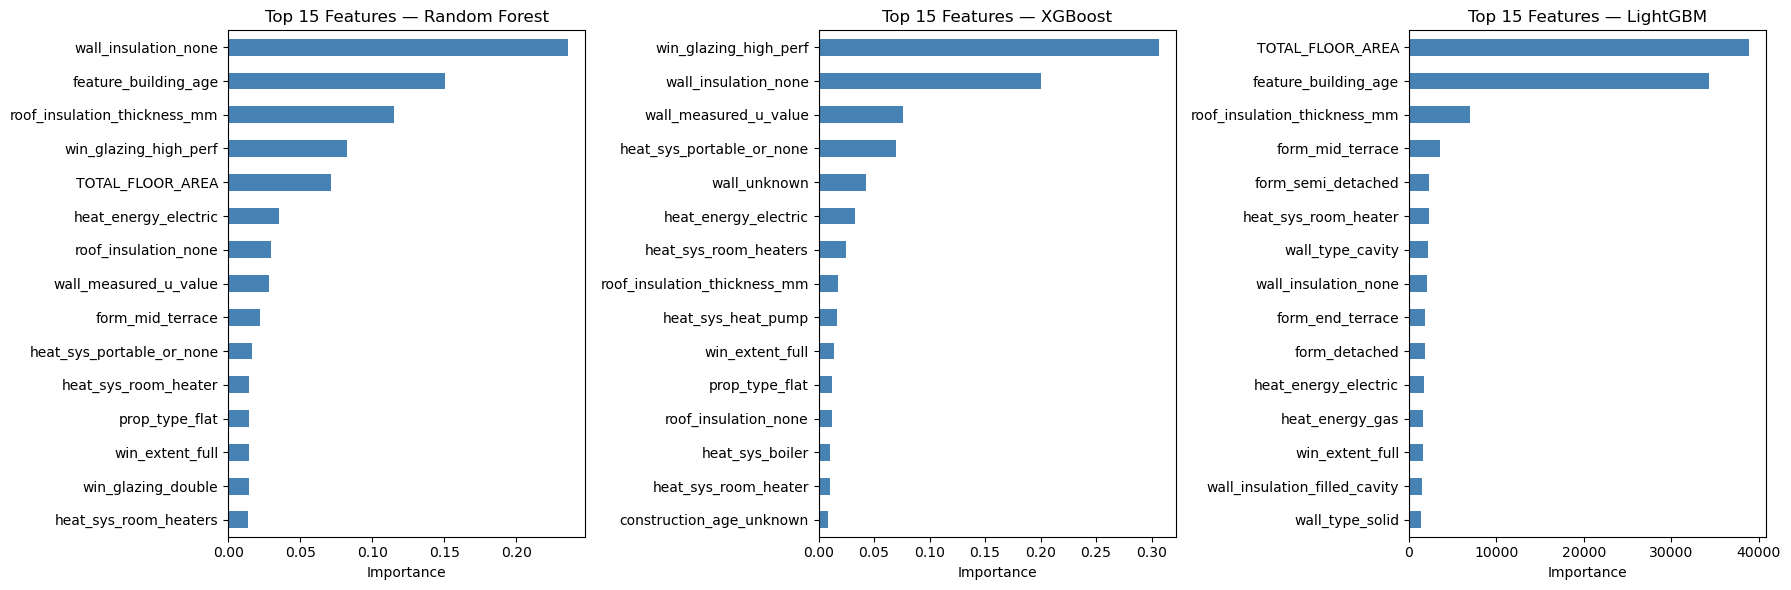

In [28]:
def get_importance(search_obj, feature_names):
    model = search_obj.best_estimator_.named_steps['model']
    importances = model.feature_importances_
    return pd.Series(importances, index=feature_names).sort_values(ascending=False)

all_feature_names = [
    name.split('__')[-1]
    for name in rf_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
]

rf_imp  = get_importance(rf_search,  all_feature_names).head(15)
xgb_imp = get_importance(xgb_search, all_feature_names).head(15)
lgb_imp = get_importance(lgb_search, all_feature_names).head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, imp, title in zip(
    axes,
    [rf_imp, xgb_imp, lgb_imp],
    ['Random Forest', 'XGBoost', 'LightGBM']
):
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 15 Features — {title}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('nonsymbolic_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary Table

All CV results in one table, with the Decision Tree baseline for direct comparison.

In [30]:
# Decision Tree baseline numbers from 03_decision_tree.ipynb
DT_DUMMY_RMSE = 11.648
DT_DUMMY_MAE  = 8.800
DT_TUNED_RMSE = 5.980
DT_TUNED_MAE  = 4.061

summary = pd.DataFrame({
    'Model': [
        'Dummy (median)',
        'Decision Tree (tuned)',
        'Random Forest (default)',
        'Random Forest (tuned)',
        'XGBoost (default)',
        'XGBoost (tuned)',
        'LightGBM (default)',
        'LightGBM (tuned)'
    ],
    'CV RMSE': [
        DT_DUMMY_RMSE,
        DT_TUNED_RMSE,
        round(-rf_default_rmse.mean(), 3),
        round(-rf_search.best_score_, 3),
        round(-xgb_default_rmse.mean(), 3),
        round(-xgb_search.best_score_, 3),
        round(-lgb_default_rmse.mean(), 3),
        round(-lgb_search.best_score_, 3)
    ],
    'CV MAE': [
        DT_DUMMY_MAE,
        DT_TUNED_MAE,
        round(-rf_default_mae.mean(), 3),
        round(-rf_tuned_mae.mean(), 3),
        round(-xgb_default_mae.mean(), 3),
        round(-xgb_tuned_mae.mean(), 3),
        round(-lgb_default_mae.mean(), 3),
        round(-lgb_tuned_mae.mean(), 3)
    ]
})

print("=== PHASE 4 RESULTS SUMMARY (10-fold CV on training set) ===")
print(summary.to_string(index=False))

summary.to_parquet('phase4_nonsymbolic_results.parquet')
print("\nResults saved to phase4_nonsymbolic_results.parquet")

=== PHASE 4 RESULTS SUMMARY (10-fold CV on training set) ===
                  Model  CV RMSE  CV MAE
         Dummy (median)   11.648   8.800
  Decision Tree (tuned)    5.980   4.061
Random Forest (default)    5.803   3.862
  Random Forest (tuned)    5.537   3.708
      XGBoost (default)    5.659   3.908
        XGBoost (tuned)    5.470   3.693
     LightGBM (default)    5.840   4.083
       LightGBM (tuned)    5.471   3.716

Results saved to phase4_nonsymbolic_results.parquet


In [32]:
# Save the best tuned models for Phase 5 (Evaluation) and Phase 6 (Iteration)
import joblib

joblib.dump(rf_search.best_estimator_,  'rf_best_model.pkl')
joblib.dump(xgb_search.best_estimator_, 'xgb_best_model.pkl')
joblib.dump(lgb_search.best_estimator_, 'lgb_best_model.pkl')

print("Three tuned models saved: rf_best_model.pkl, xgb_best_model.pkl, lgb_best_model.pkl")


Three tuned models saved: rf_best_model.pkl, xgb_best_model.pkl, lgb_best_model.pkl
Ready for Phase 5 (Evaluation) and Phase 6 (Iteration).
